<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/pytorch/Regression_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [163]:
! pip install opendatasets

In [164]:
import opendatasets as od

In [165]:
od.download('https://www.kaggle.com/datasets/andonians/random-linear-regression')

Skipping, found downloaded files in "./random-linear-regression" (use force=True to force download)


In [166]:
import pandas as pd
import matplotlib.pyplot as plt


In [167]:
df_train = pd.read_csv('/content/random-linear-regression/train.csv')
df_test = pd.read_csv('/content/random-linear-regression/test.csv')

In [168]:
df_train.sample(4)

,x,y
206,24.0,21.596356
610,62.0,62.153134
332,74.0,73.596434
61,74.0,71.610103


In [169]:
df_train.isnull().sum()

,0
x,0
y,1


In [170]:
df_train.min()

,0
x,0.000000
y,-3.839981


In [171]:
df_train.max()

,0
x,3530.157369
y,108.871618


In [172]:
df_test.sample(4)

,x,y
1,21,23.177279
206,40,48.098431
260,16,16.828397
297,55,54.090637


In [173]:
df_test.min()

,0
x,0.000000
y,-3.467884


In [174]:
df_test.max()

,0
x,100.000000
y,105.591837


In [175]:
df_test.isnull().sum()

,0
x,0
y,0


In [176]:
df_train = df_train.fillna(df_train.mean(numeric_only=True))
# df_train['y'] = df_train['y'].fillna(df_train['y'].mean())

In [177]:
X_trian = df_train.drop('y', axis=1)
y_train = df_train['y']
X_test = df_test.drop('y', axis=1)
y_test = df_test['y']

In [178]:
from sklearn.preprocessing import StandardScaler

In [179]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_trian)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))

Text(0, 0.5, 'y')

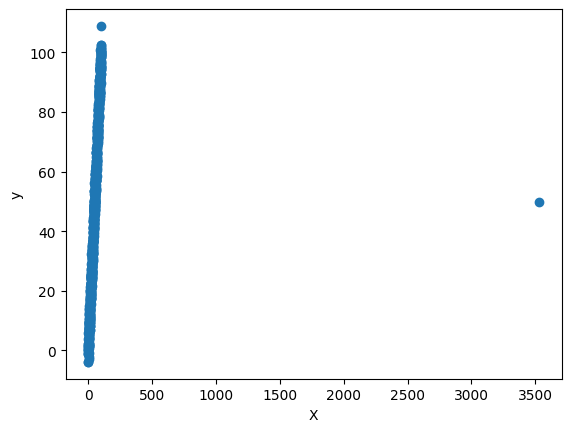

In [180]:
plt.scatter(X_trian, y_train)
plt.xlabel('X')
plt.ylabel('y')

Text(0, 0.5, 'y')

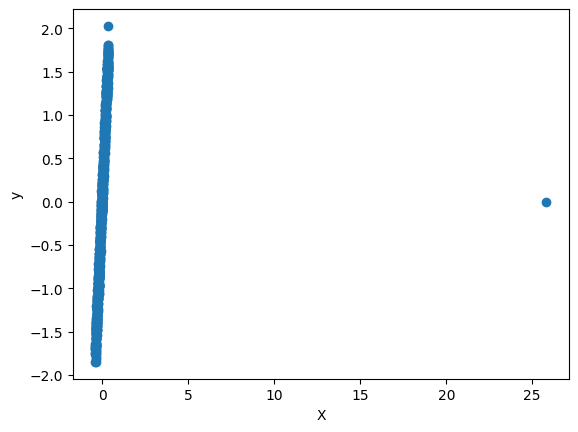

In [181]:
plt.scatter(X_train_scaled, y_train_scaled)
plt.xlabel('X')
plt.ylabel('y')

In [182]:
import torch
import torch.nn as nn
import torch.optim as optim

In [183]:
x_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
x_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

In [184]:
# y_test_tensor

In [185]:
x_train_tensor.shape

torch.Size([700, 1])

In [186]:
# Model
class MyRegressionNNmodel(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )

    def forward(self, x):
        return self.network(x)

In [187]:
model = MyRegressionNNmodel(x_train_tensor.shape[1])

In [188]:
print("Layer 1 weights:", model.network[0].weight)
print("Layer 1 bias:", model.network[0].bias)

Layer 1 weights: Parameter containing:
tensor([[-0.5607],
        [-0.7975],
        [ 0.2001],
        [-0.1660],
        [-0.2176],
        [-0.9191],
        [ 0.2224],
        [ 0.0019],
        [-0.9148],
        [-0.1871]], requires_grad=True)
Layer 1 bias: Parameter containing:
tensor([ 0.3983,  0.1539,  0.3920, -0.1237, -0.7176,  0.0078,  0.2944, -0.4095,
         0.8663,  0.2388], requires_grad=True)


In [189]:
# Loss calculation
Loss = nn.MSELoss()

In [190]:
# weights & bias
epochs = 500
optimizer = optim.SGD(model.parameters(), lr = 0.01)

for epoch in range(epochs):
  y_pred = model(x_train_tensor)
  loss = Loss(y_pred, y_train_tensor)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, Loss: {loss.item()}")

Epoch: 0, Loss: 1.6012595891952515
Epoch: 10, Loss: 1.155824899673462
Epoch: 20, Loss: 0.9897050261497498
Epoch: 30, Loss: 0.9119446873664856
Epoch: 40, Loss: 0.8657422065734863
Epoch: 50, Loss: 0.8314614295959473
Epoch: 60, Loss: 0.8017860651016235
Epoch: 70, Loss: 0.7739102840423584
Epoch: 80, Loss: 0.746728777885437
Epoch: 90, Loss: 0.7197558283805847
Epoch: 100, Loss: 0.692901611328125
Epoch: 110, Loss: 0.6660672426223755
Epoch: 120, Loss: 0.6393176913261414
Epoch: 130, Loss: 0.6126334071159363
Epoch: 140, Loss: 0.5862464904785156
Epoch: 150, Loss: 0.5605480074882507
Epoch: 160, Loss: 0.535688579082489
Epoch: 170, Loss: 0.5114478468894958
Epoch: 180, Loss: 0.48783716559410095
Epoch: 190, Loss: 0.46487775444984436
Epoch: 200, Loss: 0.442556232213974
Epoch: 210, Loss: 0.42090097069740295
Epoch: 220, Loss: 0.3999456465244293
Epoch: 230, Loss: 0.3797427713871002
Epoch: 240, Loss: 0.3602701425552368
Epoch: 250, Loss: 0.3415694236755371
Epoch: 260, Loss: 0.3236040472984314
Epoch: 270, Lo

In [191]:
# print(torch.isnan(x_train_tensor).any())
# print(torch.isnan(y_train_tensor).any())


tensor(False)
tensor(False)


In [193]:
with torch.no_grad():
  y_pred = model(x_test_tensor)
  test_loss = Loss(y_pred, y_test_tensor)
  print(f"Test Loss: {test_loss}")

Test Loss: 0.07487332820892334
